# 12 - Visualizaciones finales para el TFM

Notebook consolidado para integrar en una rama nueva y fusionar posteriormente con `main`.

## Selección visual definitiva

- **Pipeline metodológico (color y BN):** versión v19.
- **Construcción de los corpus:** figura completa nueva, desde extracción hasta publicaciones relevantes.
- **Distribución comparada de categorías:** barras horizontales agrupadas.
- **Evolución mensual:** versión con etiquetas al final de las líneas.
- **Post-corrección de "hijo en apuros":** barras antes/después.
- **BERTopic EEUU y España:** gráficos tipo lollipop.

Todas las figuras se guardan en `docs/overleaf/figures/` en PNG y PDF.


## 0. Configuracion reproducible

No es una visualizacion. Prepara rutas, estilo y funciones auxiliares.

Las figuras se guardan en PNG (borrador) y PDF (Overleaf, maxima calidad).


In [1]:
from pathlib import Path
import warnings
import textwrap
import re

try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.ticker import FuncFormatter, MaxNLocator
    from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle, Rectangle, Polygon, Wedge
    from matplotlib.lines import Line2D
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        f"Falta la libreria '{exc.name}'. Instala las dependencias desde la raiz del repositorio con: "
        "pip install -r requirements.txt"
    ) from exc

warnings.filterwarnings("ignore", category=FutureWarning)

# Si ejecutas este notebook fuera del repo, puedes poner aqui la ruta manualmente.
# Ejemplo Mac: REPO_ROOT_OVERRIDE = "/Users/tu_usuario/Desktop/tfm_repo"
# Ejemplo Windows: REPO_ROOT_OVERRIDE = r"C:\\Users\\tu_usuario\\Desktop\\tfm_repo"
REPO_ROOT_OVERRIDE = None


def find_repo_root(start=None):
    """Busca la raiz del repositorio sin depender de rutas absolutas."""
    if REPO_ROOT_OVERRIDE:
        candidate = Path(REPO_ROOT_OVERRIDE).expanduser().resolve()
        if (candidate / "docs" / "overleaf").exists():
            return candidate
        raise FileNotFoundError(f"La ruta indicada en REPO_ROOT_OVERRIDE no parece el repo: {candidate}")

    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    search_bases = [start, *start.parents]

    # Busqueda normal: si el notebook esta dentro del repo.
    for candidate in search_bases:
        has_overleaf = (candidate / "docs" / "overleaf").exists()
        has_repo_marker = (candidate / "notebooks").exists() or (candidate / ".git").exists() or (candidate / "requirements.txt").exists()
        if has_overleaf and has_repo_marker:
            return candidate

    # Busqueda suave: si el notebook esta en Downloads/Escritorio y el repo esta cerca.
    home = Path.home()
    for base in [home / "Desktop", home / "Escritorio", home / "Documents", home / "Documentos", home / "Downloads", home / "Descargas"]:
        if base.exists():
            for candidate in list(base.glob("*"))[:300]:
                if candidate.is_dir() and (candidate / "docs" / "overleaf").exists() and (candidate / "notebooks").exists():
                    return candidate.resolve()

    raise FileNotFoundError(
        "No encuentro la raiz del repositorio. Abre Jupyter desde la carpeta del repo o rellena REPO_ROOT_OVERRIDE."
    )


def find_file(filename, root):
    """Encuentra un archivo dentro del repo aunque cambie ligeramente de subcarpeta."""
    preferred = [
        root / "data" / "raw" / filename,
        root / "data" / "processed" / filename,
        root / filename,
    ]
    for path in preferred:
        if path.exists():
            return path

    matches = [
        p for p in root.rglob(filename)
        if "__MACOSX" not in str(p) and ".git" not in str(p) and ".venv" not in str(p)
    ]
    if not matches:
        raise FileNotFoundError(f"No encuentro {filename} dentro de {root}")
    return matches[0]


REPO_ROOT = find_repo_root()
DATA_RAW = REPO_ROOT / "data" / "raw"
OVERLEAF = REPO_ROOT / "docs" / "overleaf"
FIG_DIR = OVERLEAF / "figures"
TABLE_DIR = OVERLEAF / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

US_CSV = find_file("scam_us_FINAL_classified.csv", REPO_ROOT)
ES_CSV = find_file("scam_es_FINAL_classified_corregido.csv", REPO_ROOT)

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 320,
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.labelsize": 10.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.16,
    "grid.linewidth": 0.7,
    "legend.frameon": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

COLORS = {
    "ink": "#1F2933",
    "muted": "#667085",
    "line": "#D0D5DD",
    "grid": "#EAECF0",
    "paper": "#FFFFFF",
    "soft": "#F8FAFC",
    "us": "#2F6B8F",
    "es": "#C75646",
    "green": "#6C8E4E",
    "gold": "#D99C2B",
    "purple": "#8D6CAB",
    "teal": "#4C7C7D",
    "grey": "#8A8F98",
}

COUNTRY_COLORS = {
    "Estados Unidos": COLORS["us"],
    "España": COLORS["es"],
    "Espana": COLORS["es"],  # alias técnico por compatibilidad
}

CATEGORY_LABELS = {
    "phishing_identity": "Phishing / robo de identidad",
    "investment_crypto": "Inversión / cripto",
    "ponzi_pyramid": "Ponzi / piramidal",
    "employment": "Empleo",
    "romance": "Romance",
    "bank_wire": "Banco / transferencias",
    "gov_impersonation": "Suplantación pública",
    "tax": "Fiscal",
    "tech_support": "Soporte técnico",
    "payment_app": "Apps de pago",
    "charity": "Caridad / donaciones",
    "corporate": "Corporativo / bursátil",
    "insurance": "Seguros",
    "not_related": "No relacionado",
}

TOPIC_STOPWORDS = {
    "a", "an", "and", "are", "as", "be", "by", "for", "from", "in", "is", "it", "of", "on", "or",
    "that", "the", "this", "to", "will", "with", "your", "you", "de", "del", "la", "el", "en", "que",
    "por", "una", "un", "los", "las", "para", "con", "se", "su", "sus", "al", "lo", "como", "mas",
    "via", "sobre", "desde", "mediante"
}


def pct_formatter(x, pos=None):
    return f"{x:.0f}%"


def label_category(code):
    return CATEGORY_LABELS.get(code, code)


def wrap_label(text, width=28):
    return "\n".join(textwrap.wrap(str(text), width=width, break_long_words=False))


def save_figure(fig, name):
    """Guarda una figura en PNG y PDF para Overleaf."""
    png_path = FIG_DIR / f"{name}.png"
    pdf_path = FIG_DIR / f"{name}.pdf"
    fig.savefig(png_path, bbox_inches="tight", facecolor="white")
    fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
    print(f"Guardado: {png_path.relative_to(REPO_ROOT)}")
    print(f"Guardado: {pdf_path.relative_to(REPO_ROOT)}")
    return png_path, pdf_path


def export_table(df, name, caption=None, label=None):
    """Exporta una tabla agregada a CSV y a LaTeX."""
    csv_path = TABLE_DIR / f"{name}.csv"
    tex_path = TABLE_DIR / f"{name}.tex"
    df.to_csv(csv_path, index=False, encoding="utf-8")
    print(f"Guardado: {csv_path.relative_to(REPO_ROOT)}")
    try:
        df.to_latex(tex_path, index=False, escape=True, caption=caption, label=label)
        print(f"Guardado: {tex_path.relative_to(REPO_ROOT)}")
    except Exception as exc:
        print(f"No se pudo exportar LaTeX para {name}: {exc}")
    return csv_path


def clean_axis(ax):
    ax.grid(axis="x", color=COLORS["grid"], linewidth=0.8)
    ax.grid(axis="y", visible=False)
    ax.tick_params(axis="both", colors=COLORS["ink"], labelsize=9.5)
    ax.xaxis.label.set_color(COLORS["muted"])
    ax.yaxis.label.set_color(COLORS["muted"])
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color("#D9DEE7")
        ax.spines[spine].set_linewidth(0.8)

print(f"Raiz del repo: {REPO_ROOT}")
print(f"CSV EEUU: {US_CSV.relative_to(REPO_ROOT)}")
print(f"CSV España: {ES_CSV.relative_to(REPO_ROOT)}")
print(f"Figuras: {FIG_DIR.relative_to(REPO_ROOT)}")
print(f"Tablas: {TABLE_DIR.relative_to(REPO_ROOT)}")

Raiz del repo: /Users/reyes/Documents/tfm_repo
CSV EEUU: data/raw/scam_us_FINAL_classified.csv
CSV España: data/raw/scam_es_FINAL_classified_corregido.csv
Figuras: docs/overleaf/figures
Tablas: docs/overleaf/tables


## 1. Carga de datos finales

Carga los corpus finales que sostienen todas las figuras.

Entradas:
- `data/raw/scam_us_FINAL_classified.csv`
- `data/raw/scam_es_FINAL_classified_corregido.csv`


In [2]:
us = pd.read_csv(US_CSV)
es = pd.read_csv(ES_CSV)

for df, country in [(us, "Estados Unidos"), (es, "España")]:
    df["country"] = country
    df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce", utc=True)
    df["month"] = df["created_at"].dt.to_period("M").astype(str)
    df["confidence_score"] = pd.to_numeric(df["confidence_score"], errors="coerce")
    for col in ["retweet_count", "reply_count", "like_count", "quote_count", "n_words", "n_hashtags", "n_mentions", "n_urls", "user_followers"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

combined = pd.concat([us, es], ignore_index=True)

print(f"EEUU:   {len(us):,} tweets")
print(f"España: {len(es):,} tweets")

/var/folders/9w/8l1cwvmj6sndy1v1qd938lv80000gn/T/ipykernel_19303/2337105487.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"] = df["created_at"].dt.to_period("M").astype(str)
/var/folders/9w/8l1cwvmj6sndy1v1qd938lv80000gn/T/ipykernel_19303/2337105487.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"] = df["created_at"].dt.to_period("M").astype(str)


EEUU:   1,928 tweets
España: 1,229 tweets


## 2. Tabla descriptiva de los corpus

**Donde:** Materiales y Metodos, despues de Estructura de los Datos.


In [3]:
def corpus_summary(df, country):
    relevant = df["is_relevant"].astype(str).str.lower().eq("true") if "is_relevant" in df.columns else pd.Series([np.nan] * len(df))
    return {
        "Corpus": country,
        "Tweets": len(df),
        "Periodo": f"{df['created_at'].min().date()} - {df['created_at'].max().date()}",
        "Relevantes (%)": round(relevant.mean() * 100, 1),
        "Palabras medias": round(df["n_words"].mean(), 1) if "n_words" in df.columns else None,
        "URLs medias": round(df["n_urls"].mean(), 2) if "n_urls" in df.columns else None,
        "Hashtags medios": round(df["n_hashtags"].mean(), 2) if "n_hashtags" in df.columns else None,
        "Likes mediana": round(df["like_count"].median(), 1) if "like_count" in df.columns else None,
        "Retweets mediana": round(df["retweet_count"].median(), 1) if "retweet_count" in df.columns else None,
        "Confianza media": round(df["confidence_score"].mean(), 3),
    }

tabla_corpus = pd.DataFrame([
    corpus_summary(us, "Estados Unidos"),
    corpus_summary(es, "España"),
])

export_table(
    tabla_corpus,
    "tabla_caracteristicas_corpus",
    caption="Características descriptivas de los corpus finales.",
    label="tab:caracteristicas_corpus",
)

display(tabla_corpus)

Guardado: docs/overleaf/tables/tabla_caracteristicas_corpus.csv
Guardado: docs/overleaf/tables/tabla_caracteristicas_corpus.tex


,Corpus,Tweets,Periodo,Relevantes (%),Palabras medias,URLs medias,Hashtags medios,Likes mediana,Retweets mediana,Confianza media
0,Estados Unidos,1928,2025-01-02 - 2025-12-31,98.1,28.3,0.97,0.55,0.0,0.0,0.596
1,España,1229,2025-01-17 - 2025-12-31,99.8,25.9,1.17,0.97,0.0,0.0,0.515


## 3a. Figura: pipeline metodológico (version con iconos)

**Donde:** Materiales y Metodos, al inicio del capitulo o en Diseno general.

**Titulo sugerido:** `Pipeline metodológico del estudio`.

**Leyenda sugerida:** `Etapas del flujo de trabajo: extraccion, preprocesamiento, exploracion tematica, clasificacion, post-correccion y analisis comparativo. Las cuatro primeras se aplican a los dos corpus; la post-correccion solo al espanol.`


Guardado: docs/overleaf/figures/fig_00a_pipeline_color.png
Guardado: docs/overleaf/figures/fig_00a_pipeline_color.pdf


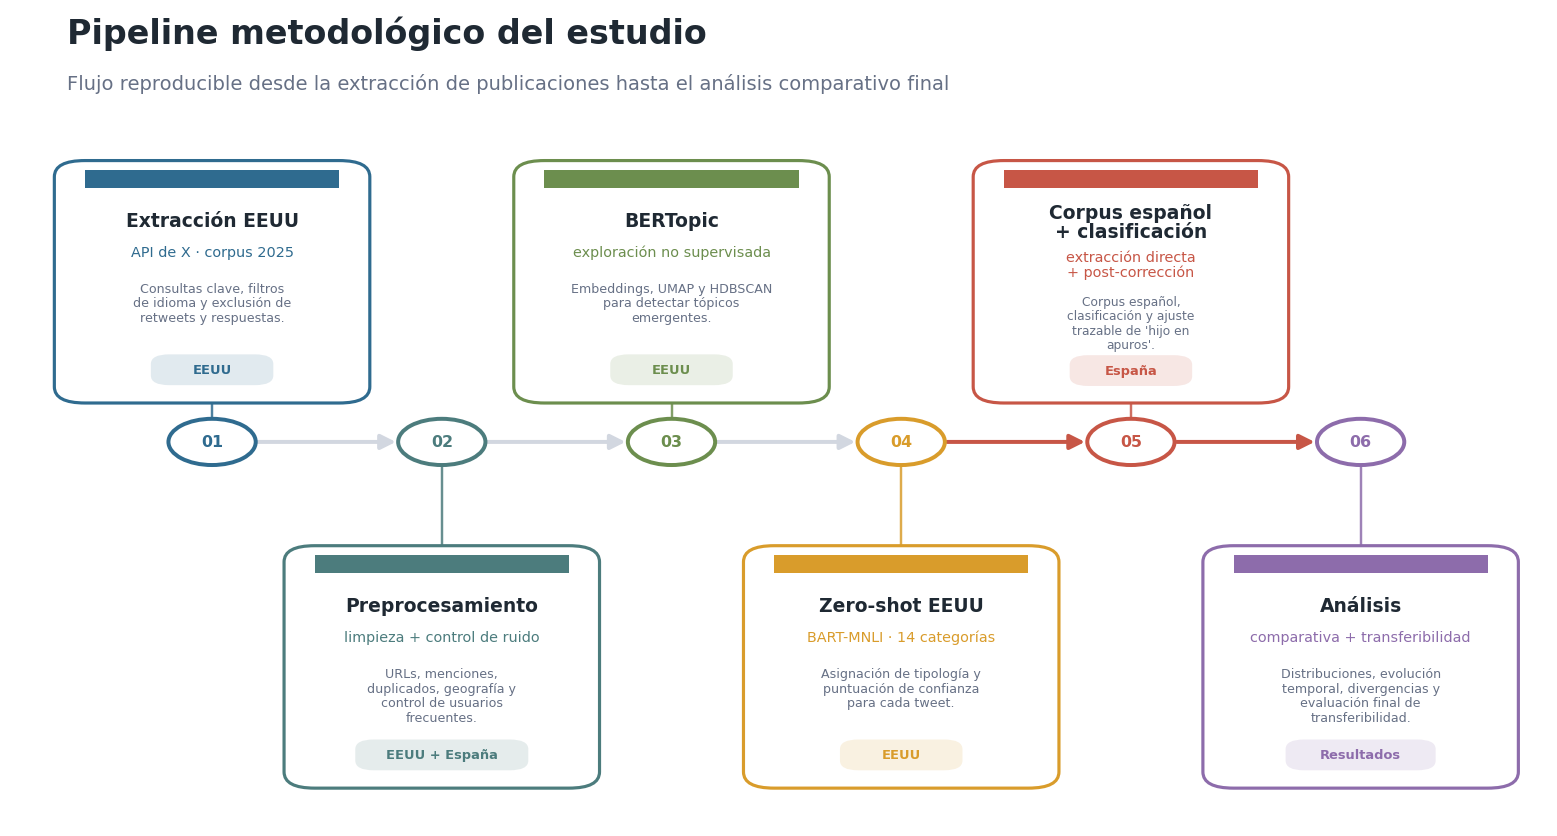

In [4]:
# Timeline metodológica actualizada según la memoria.
# Versión v19: mantiene arriba el título negro del bloque rojo y baja el subtítulo rojo y el texto gris.

stages = [
    {
        "num": "01",
        "title": "Extracción EEUU",
        "subtitle": "API de X · corpus 2025",
        "desc": "Consultas clave, filtros de idioma y exclusión de retweets y respuestas.",
        "color": COLORS["us"],
        "scope": "EEUU",
        "row": "top",
    },
    {
        "num": "02",
        "title": "Preprocesamiento",
        "subtitle": "limpieza + control de ruido",
        "desc": "URLs, menciones, duplicados, geografía y control de usuarios frecuentes.",
        "color": COLORS["teal"],
        "scope": "EEUU + España",
        "row": "bottom",
    },
    {
        "num": "03",
        "title": "BERTopic",
        "subtitle": "exploración no supervisada",
        "desc": "Embeddings, UMAP y HDBSCAN para detectar tópicos emergentes.",
        "color": COLORS["green"],
        "scope": "EEUU",
        "row": "top",
    },
    {
        "num": "04",
        "title": "Zero-shot EEUU",
        "subtitle": "BART-MNLI · 14 categorías",
        "desc": "Asignación de tipología y puntuación de confianza para cada tweet.",
        "color": COLORS["gold"],
        "scope": "EEUU",
        "row": "bottom",
    },
    {
        "num": "05",
        "title": "Corpus español\n+ clasificación",
        "subtitle": "extracción directa\n+ post-corrección",
        "desc": "Corpus español, clasificación y ajuste trazable de 'hijo en apuros'.",
        "color": COLORS["es"],
        "scope": "España",
        "row": "top",
    },
    {
        "num": "06",
        "title": "Análisis",
        "subtitle": "comparativa + transferibilidad",
        "desc": "Distribuciones, evolución temporal, divergencias y evaluación final de transferibilidad.",
        "color": COLORS["purple"],
        "scope": "Resultados",
        "row": "bottom",
    },
]

fig, ax = plt.subplots(figsize=(15.2, 8.1))
ax.set_axis_off()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.text(0.035, 0.962, "Pipeline metodológico del estudio", fontsize=18.5, fontweight="bold", color=COLORS["ink"], ha="left")
ax.text(0.035, 0.905, "Flujo reproducible desde la extracción de publicaciones hasta el análisis comparativo final", fontsize=10.8, color=COLORS["muted"], ha="left")

# Mas aire vertical para que las tarjetas superiores no choquen con el subtitulo.
x_positions = np.linspace(0.13, 0.88, len(stages))
y_line = 0.47
card_w, card_h = 0.182, 0.275

gray_line = "#D2D7E0"
red_line = COLORS["es"]
arrow_colors = [gray_line, gray_line, gray_line, red_line, red_line]

for i in range(len(x_positions) - 1):
    ax.add_patch(FancyArrowPatch(
        (x_positions[i] + 0.03, y_line),
        (x_positions[i + 1] - 0.03, y_line),
        arrowstyle="-|>",
        mutation_scale=17,
        linewidth=2.2,
        color=arrow_colors[i],
        zorder=1,
        shrinkA=0,
        shrinkB=0,
    ))

for x, st in zip(x_positions, stages):
    color = st["color"]
    ax.add_patch(Circle((x, y_line), 0.0285, facecolor="white", edgecolor=color, linewidth=2.2, zorder=4))
    ax.text(x, y_line, st["num"], ha="center", va="center", fontsize=8.8, fontweight="bold", color=color, zorder=5)

    card_above = st["row"] == "top"
    card_y = 0.53 if card_above else 0.055
    connector_y = card_y if card_above else card_y + card_h
    ax.plot([x, x], [y_line + (0.03 if card_above else -0.03), connector_y], color=color, linewidth=1.35, alpha=0.85, zorder=2)

    ax.add_patch(FancyBboxPatch(
        (x - card_w / 2, card_y), card_w, card_h,
        boxstyle="round,pad=0.012,rounding_size=0.020",
        facecolor="#FFFFFF", edgecolor=color, linewidth=1.75, zorder=3
    ))
    ax.add_patch(Rectangle(
        (x - card_w / 2 + 0.008, card_y + card_h - 0.022),
        card_w - 0.016, 0.022,
        facecolor=color, edgecolor="none", zorder=4
    ))

    center_x = x
    title_y = card_y + card_h - (0.040 if st["num"] == "05" else 0.050)
    subtitle_y = title_y - (0.042 if st['num'] != '05' else 0.058)
    desc_y = subtitle_y - (0.046 if st['num'] != '05' else 0.056)

    ax.text(center_x, title_y, st["title"], fontsize=10.4, fontweight="bold", color=COLORS["ink"], ha="center", va="top", zorder=5, linespacing=1.05)
    ax.text(center_x, subtitle_y, st["subtitle"], fontsize=7.95, color=color, ha="center", va="top", zorder=5, linespacing=1.05)
    ax.text(center_x, desc_y, wrap_label(st["desc"], 24 if st["num"] == "05" else 26), fontsize=6.8 if st["num"] == "05" else 7.0, color=COLORS["muted"], ha="center", va="top", linespacing=1.15, zorder=5)

    tag_w = 0.072 if st["scope"] in ("EEUU", "España") else 0.105
    if st["scope"] == "Resultados":
        tag_w = 0.09
    tag_y = card_y + (0.013 if st["num"] == "05" else 0.014)
    ax.add_patch(FancyBboxPatch(
        (x - tag_w / 2, tag_y), tag_w, 0.030,
        boxstyle="round,pad=0.004,rounding_size=0.012",
        facecolor=color, edgecolor="none", alpha=0.14, zorder=4
    ))
    ax.text(x, tag_y + 0.015, st["scope"], fontsize=7.2, color=color, ha="center", va="center", fontweight="bold", zorder=5)

save_figure(fig, "fig_00a_pipeline_color")
plt.show()


## 3b. Figura: pipeline metodológico (version blanco y negro)

Version alternativa, sobria, estilo paper cientifico. Util si quereis usar una version en cuerpo y otra en anexo, o si preferis tono mas formal.


Guardado: docs/overleaf/figures/fig_00b_pipeline_bn.png
Guardado: docs/overleaf/figures/fig_00b_pipeline_bn.pdf


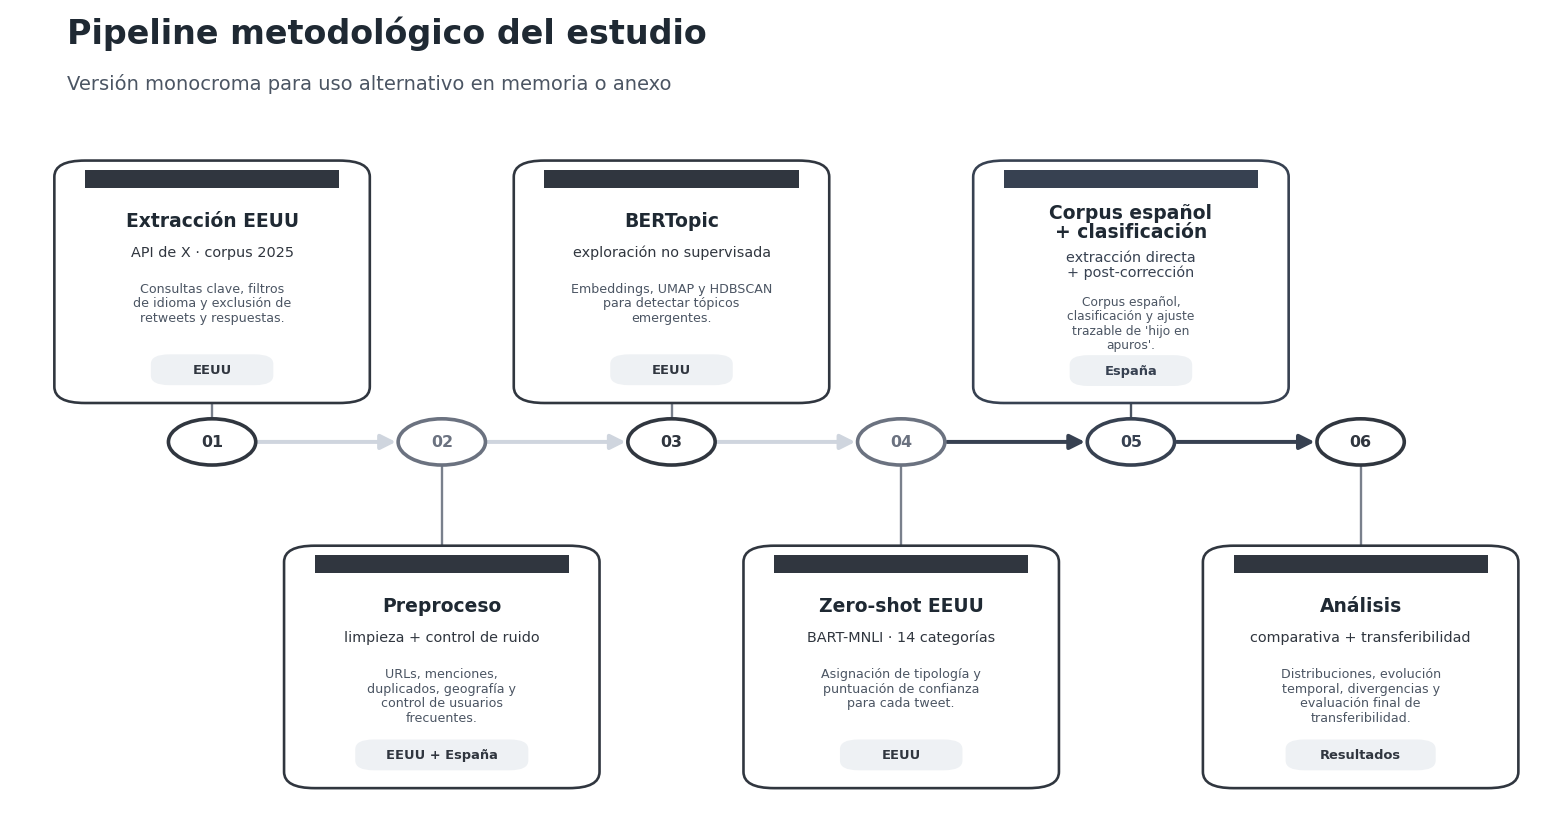

In [5]:
# Versión monocroma del pipeline actualizado.
# Versión v19: mantiene arriba el título negro del bloque rojo y baja el subtítulo rojo y el texto gris.

stages_bn = [
    {"num": "01", "title": "Extracción EEUU", "subtitle": "API de X · corpus 2025", "desc": "Consultas clave, filtros de idioma y exclusión de retweets y respuestas.", "scope": "EEUU", "row": "top"},
    {"num": "02", "title": "Preproceso", "subtitle": "limpieza + control de ruido", "desc": "URLs, menciones, duplicados, geografía y control de usuarios frecuentes.", "scope": "EEUU + España", "row": "bottom"},
    {"num": "03", "title": "BERTopic", "subtitle": "exploración no supervisada", "desc": "Embeddings, UMAP y HDBSCAN para detectar tópicos emergentes.", "scope": "EEUU", "row": "top"},
    {"num": "04", "title": "Zero-shot EEUU", "subtitle": "BART-MNLI · 14 categorías", "desc": "Asignación de tipología y puntuación de confianza para cada tweet.", "scope": "EEUU", "row": "bottom"},
    {"num": "05", "title": "Corpus español\n+ clasificación", "subtitle": "extracción directa\n+ post-corrección", "desc": "Corpus español, clasificación y ajuste trazable de 'hijo en apuros'.", "scope": "España", "row": "top"},
    {"num": "06", "title": "Análisis", "subtitle": "comparativa + transferibilidad", "desc": "Distribuciones, evolución temporal, divergencias y evaluación final de transferibilidad.", "scope": "Resultados", "row": "bottom"},
]

INK = "#1F2933"
TEXT = "#4B5563"
LINE = "#CFD5DE"
BORDER = "#30363F"
FILL = "#FFFFFF"
TAG_FILL = "#EEF1F4"
ACCENT = "#6B7280"
DARK_ACCENT = "#374151"

fig, ax = plt.subplots(figsize=(15.2, 8.1))
ax.set_axis_off()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.text(0.035, 0.962, "Pipeline metodológico del estudio", fontsize=18.5, fontweight="bold", color=INK, ha="left")
ax.text(0.035, 0.905, "Versión monocroma para uso alternativo en memoria o anexo", fontsize=10.8, color=TEXT, ha="left")

x_positions = np.linspace(0.13, 0.88, len(stages_bn))
y_line = 0.47
card_w, card_h = 0.182, 0.275
arrow_colors = [LINE, LINE, LINE, DARK_ACCENT, DARK_ACCENT]

for i in range(len(x_positions) - 1):
    ax.add_patch(FancyArrowPatch(
        (x_positions[i] + 0.03, y_line),
        (x_positions[i + 1] - 0.03, y_line),
        arrowstyle="-|>",
        mutation_scale=17,
        linewidth=2.2,
        color=arrow_colors[i],
        zorder=1,
        shrinkA=0,
        shrinkB=0,
    ))

for x, st in zip(x_positions, stages_bn):
    node_edge = DARK_ACCENT if st["num"] == "05" else BORDER if st["num"] in ("01", "03", "06") else ACCENT
    connector_edge = DARK_ACCENT if st["num"] == "05" else ACCENT
    ax.add_patch(Circle((x, y_line), 0.0285, facecolor=FILL, edgecolor=node_edge, linewidth=2.0, zorder=4))
    ax.text(x, y_line, st["num"], ha="center", va="center", fontsize=8.8, fontweight="bold", color=node_edge, zorder=5)

    card_above = st["row"] == "top"
    card_y = 0.53 if card_above else 0.055
    connector_y = card_y if card_above else card_y + card_h
    ax.plot([x, x], [y_line + (0.03 if card_above else -0.03), connector_y], color=connector_edge, linewidth=1.3, alpha=0.9, zorder=2)

    edge = DARK_ACCENT if st["num"] == "05" else BORDER
    ax.add_patch(FancyBboxPatch((x - card_w / 2, card_y), card_w, card_h, boxstyle="round,pad=0.012,rounding_size=0.020", facecolor=FILL, edgecolor=edge, linewidth=1.45, zorder=3))
    ax.add_patch(Rectangle((x - card_w / 2 + 0.008, card_y + card_h - 0.022), card_w - 0.016, 0.022, facecolor=edge, edgecolor="none", zorder=4))

    center_x = x
    title_y = card_y + card_h - (0.040 if st["num"] == "05" else 0.050)
    subtitle_y = title_y - (0.042 if st['num'] != '05' else 0.058)
    desc_y = subtitle_y - (0.046 if st['num'] != '05' else 0.056)

    ax.text(center_x, title_y, st["title"], fontsize=10.4, fontweight="bold", color=INK, ha="center", va="top", zorder=5, linespacing=1.05)
    ax.text(center_x, subtitle_y, st["subtitle"], fontsize=7.95, color=edge, ha="center", va="top", zorder=5, linespacing=1.05)
    ax.text(center_x, desc_y, wrap_label(st["desc"], 24 if st["num"] == "05" else 26), fontsize=6.8 if st["num"] == "05" else 7.0, color=TEXT, ha="center", va="top", linespacing=1.15, zorder=5)

    tag_w = 0.072 if st["scope"] in ("EEUU", "España") else 0.105
    if st["scope"] == "Resultados":
        tag_w = 0.09
    tag_y = card_y + (0.013 if st["num"] == "05" else 0.014)
    ax.add_patch(FancyBboxPatch((x - tag_w / 2, tag_y), tag_w, 0.030, boxstyle="round,pad=0.004,rounding_size=0.012", facecolor=TAG_FILL, edgecolor="none", zorder=4))
    ax.text(x, tag_y + 0.015, st["scope"], fontsize=7.2, color=edge, ha="center", va="center", fontweight="bold", zorder=5)

save_figure(fig, "fig_00b_pipeline_bn")
plt.show()


## 4. Figura: construcción y clasificación completa de los corpus

**Dónde:** Materiales y Métodos, en la subsección de construcción del corpus.

**Título sugerido:** `Construcción y clasificación de los corpus de análisis`.

**Lectura:** integra extracción, depuración, corpus final, clasificación BART-MNLI, categoría residual y post-corrección española.


Guardado: docs/overleaf/figures/fig_01_flujo_construccion_corpus.png
Guardado: docs/overleaf/figures/fig_01_flujo_construccion_corpus.pdf


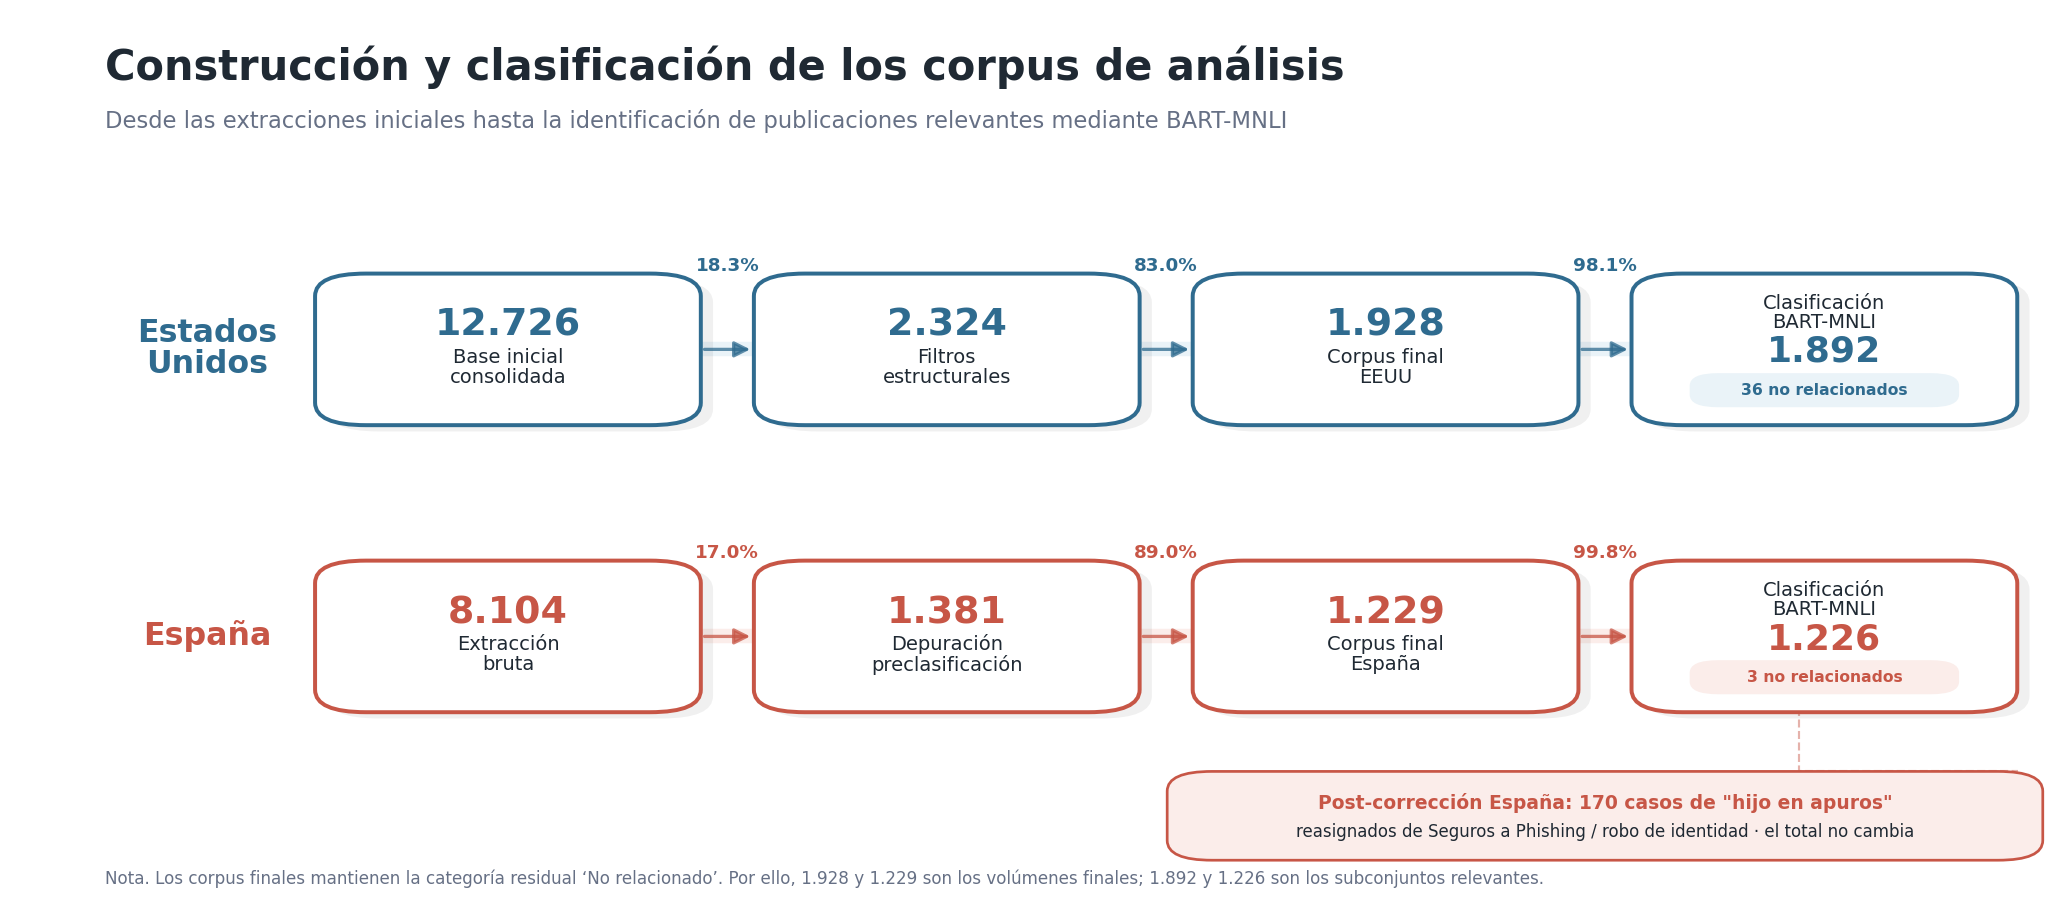

In [14]:
# Figura consolidada: construcción + clasificación + post-corrección.
# Las etapas intermedias se leen desde CSV si existen; en caso contrario usa
# las cifras documentadas y verificadas en la memoria/notebooks.

def safe_len_from_csv(filename, fallback):
    try:
        path = find_file(filename, REPO_ROOT)
        return len(pd.read_csv(path))
    except Exception:
        print(f"Aviso: no se encontró {filename}; se usa la cifra documentada {fallback:,}.".replace(",", "."))
        return fallback


def count_relevant(df):
    if "is_relevant" not in df.columns:
        return len(df)
    return int(df["is_relevant"].astype(str).str.lower().eq("true").sum())


def fmt_int(value):
    return f"{int(value):,}".replace(",", ".")


def retention_pct(new_value, old_value):
    if not old_value:
        return "n.d."
    return f"{new_value / old_value * 100:.1f}%"


us_initial = safe_len_from_csv("scam_us_CONSOLIDATED_dedup.csv", 12726)
us_filtered = safe_len_from_csv("scam_us_CONSOLIDATED_clean.csv", 2324)
us_final = len(us)
us_relevant = count_relevant(us)
us_not_related = us_final - us_relevant

es_initial = safe_len_from_csv("scam_es_FINAL_raw.csv", 8104)
es_filtered = safe_len_from_csv("scam_es_FINAL_clean.csv", 1381)
es_final = len(es)
es_relevant = count_relevant(es)
es_not_related = es_final - es_relevant

if "predicted_category_original" in es.columns:
    es_before = es["predicted_category_original"].fillna(es["predicted_category"])
    corrected_n = int(es_before.ne(es["predicted_category"]).sum())
else:
    corrected_n = int(es.get("correccion_aplicada", pd.Series(False, index=es.index)).astype(str).str.lower().eq("true").sum())

rows = {
    "Estados Unidos": {
        "color": COUNTRY_COLORS["Estados Unidos"],
        "light": "#EAF3F8",
        "steps": [
            ("Base inicial\nconsolidada", us_initial),
            ("Filtros\nestructurales", us_filtered),
            ("Corpus final\nEEUU", us_final),
            ("Clasificación\nBART-MNLI", us_relevant),
        ],
        "residual": us_not_related,
    },
    "España": {
        "color": COUNTRY_COLORS["España"],
        "light": "#FBEDEA",
        "steps": [
            ("Extracción\nbruta", es_initial),
            ("Depuración\npreclasificación", es_filtered),
            ("Corpus final\nEspaña", es_final),
            ("Clasificación\nBART-MNLI", es_relevant),
        ],
        "residual": es_not_related,
    },
}

fig, ax = plt.subplots(figsize=(16, 7.2))
ax.set_axis_off()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.text(
    0.045, 0.925,
    "Construcción y clasificación de los corpus de análisis",
    fontsize=23, fontweight="bold", color=COLORS["ink"], ha="left"
)
ax.text(
    0.045, 0.872,
    "Desde las extracciones iniciales hasta la identificación de publicaciones relevantes mediante BART-MNLI",
    fontsize=12.5, color=COLORS["muted"], ha="left"
)

ys = {"Estados Unidos": 0.625, "España": 0.305}
box_w, box_h = 0.165, 0.145

# Layout automático: 4 globos con separación homogénea
n_boxes = 4
left_boxes = 0.16
right_boxes = 0.97

usable_width = right_boxes - left_boxes
gap = (usable_width - n_boxes * box_w) / (n_boxes - 1)

xs = [
    left_boxes + box_w / 2 + i * (box_w + gap)
    for i in range(n_boxes)
]


def draw_complete_box(ax, x, y, title, value, color, light, is_classification=False, residual=None):
    # Caja y sombra
    ax.add_patch(FancyBboxPatch(
        (x - box_w / 2 + 0.006, y - box_h / 2 - 0.007),
        box_w, box_h,
        boxstyle="round,pad=0.012,rounding_size=0.025",
        linewidth=0, facecolor="#000000", alpha=0.06, zorder=1,
    ))
    ax.add_patch(FancyBboxPatch(
        (x - box_w / 2, y - box_h / 2),
        box_w, box_h,
        boxstyle="round,pad=0.012,rounding_size=0.025",
        linewidth=2.2, edgecolor=color, facecolor="white", zorder=2,
    ))

    # Referencias internas del globo
    top = y + box_h / 2
    bottom = y - box_h / 2

    if is_classification:
        ax.text(
            x, top - 0.22 * box_h,
            title,
            ha="center", va="center",
            fontsize=10.8, color=COLORS["ink"],
            linespacing=1.02, zorder=3
        )

        ax.text(
            x, y - 0.02 * box_h,
            fmt_int(value),
            ha="center", va="center",
            fontsize=20, fontweight="bold",
            color=color, zorder=3
        )

        ax.text(
            x, y - 0.27 * box_h,
            "relevantes",
            ha="center", va="center",
            fontsize=10.8, color=COLORS["ink"], zorder=3
        )

        pill_w, pill_h = 0.124, 0.030
        pill_y = bottom + 0.012

        ax.add_patch(FancyBboxPatch(
            (x - pill_w / 2, pill_y), pill_w, pill_h,
            boxstyle="round,pad=0.004,rounding_size=0.014",
            linewidth=0, facecolor=light, zorder=3,
        ))

        ax.text(
            x, pill_y + pill_h / 2,
            f"{fmt_int(residual)} no relacionados",
            ha="center", va="center",
            fontsize=8.7, color=color,
            fontweight="bold", zorder=4
        )

    else:
        ax.text(
            x, y + 0.18 * box_h,
            fmt_int(value),
            ha="center", va="center",
            fontsize=21, fontweight="bold",
            color=color, zorder=3
        )

        ax.text(
            x, y - 0.14 * box_h,
            title,
            ha="center", va="center",
            fontsize=10.8, color=COLORS["ink"],
            linespacing=1.05, zorder=3
        )

def draw_complete_arrow(ax, x1, x2, y, color, label):
    start = x1 + box_w / 2 + 0.012
    end = x2 - box_w / 2 - 0.012
    ax.add_patch(FancyArrowPatch(
        (start, y), (end, y), arrowstyle="-|>", mutation_scale=18,
        linewidth=1.8, color=color, alpha=0.75, zorder=1,
    ))
    ax.text(
        (start + end) / 2, y + 0.093, label,
        ha="center", va="center", fontsize=10.2, fontweight="bold", color=color,
        bbox={"boxstyle": "round,pad=0.16", "facecolor": "white", "edgecolor": "none", "alpha": 0.96},
        zorder=5,
    )


for country, info in rows.items():
    y = ys[country]
    color = info["color"]
    light = info["light"]

    country_label = "Estados\nUnidos" if country == "Estados Unidos" else country

    ax.text(
        0.095,
        y,
        country_label,
        ha="center",
        va="center",
        multialignment="center",
        fontsize=17.5,
        fontweight="bold",
        color=color,
        linespacing=1.0,
        zorder=4,
    )

    ax.plot(
        [xs[0] - box_w / 2, xs[-1] + box_w / 2],
        [y, y],
        linewidth=8,
        color=light,
        solid_capstyle="round",
        zorder=0,
    )

    for i, ((title, value), x) in enumerate(zip(info["steps"], xs)):
        draw_complete_box(
            ax, x, y, title, value, color, light,
            is_classification=(i == 3),
            residual=info["residual"] if i == 3 else None,
        )

    values = [step[1] for step in info["steps"]]
    for i in range(3):
        draw_complete_arrow(
            ax,
            xs[i],
            xs[i + 1],
            y,
            color,
            retention_pct(values[i + 1], values[i])
        )

# La post-corrección no altera el volumen final; únicamente cambia la categoría.
call_x, call_y = (xs[2] + xs[3]) / 2, 0.105
call_w, call_h = 0.405, 0.075
ax.plot([0.875, 0.875, call_x + call_w / 2], [0.225, 0.155, 0.155], color=COUNTRY_COLORS["España"], linewidth=1.2, alpha=0.45, linestyle="--", zorder=0)
ax.add_patch(FancyBboxPatch(
    (call_x - call_w / 2, call_y - call_h / 2), call_w, call_h,
    boxstyle="round,pad=0.012,rounding_size=0.022",
    linewidth=1.5, edgecolor=COUNTRY_COLORS["España"], facecolor="#FBEDEA", zorder=2,
))
ax.text(call_x, call_y + 0.014, f'Post-corrección España: {fmt_int(corrected_n)} casos de "hijo en apuros"', ha="center", va="center", fontsize=10.4, fontweight="bold", color=COUNTRY_COLORS["España"])
ax.text(call_x, call_y - 0.018, "reasignados de Seguros a Phishing / robo de identidad · el total no cambia", ha="center", va="center", fontsize=9.2, color=COLORS["ink"])

ax.text(
    0.045, 0.025,
    "Nota. Los corpus finales mantienen la categoría residual ‘No relacionado’. "
    "Por ello, 1.928 y 1.229 son los volúmenes finales; 1.892 y 1.226 son los subconjuntos relevantes.",
    ha="left", va="bottom", fontsize=9.3, color=COLORS["muted"],
)

fig.tight_layout()
save_figure(fig, "fig_01_flujo_construccion_corpus")
plt.show()


## 5. Figura y tabla: distribución comparada de categorías

**Dónde:** Resultados, primera visualización comparativa.

**Versión elegida:** barras horizontales agrupadas de `mejora-visualizaciones`.


Guardado: docs/overleaf/tables/tabla_distribucion_categorias.csv
Guardado: docs/overleaf/tables/tabla_distribucion_categorias.tex


,Categoría,EEUU n,EEUU %,España n,España %,Diferencia España-EEUU (p.p.)
0,Phishing / robo de identidad,636,33.0,766.0,62.3,29.3
1,Ponzi / piramidal,298,15.5,7.0,0.6,-14.9
2,Inversión / cripto,293,15.2,163.0,13.3,-1.9
3,Empleo,248,12.9,44.0,3.6,-9.3
4,Romance,194,10.1,23.0,1.9,-8.2
5,Banco / transferencias,57,3.0,115.0,9.4,6.4
6,Soporte técnico,43,2.2,2.0,0.2,-2.1
7,Apps de pago,37,1.9,2.0,0.2,-1.8
8,No relacionado,36,1.9,3.0,0.2,-1.6
9,Caridad / donaciones,34,1.8,19.0,1.5,-0.2


Guardado: docs/overleaf/figures/fig_02_distribucion_categorias_comparada.png
Guardado: docs/overleaf/figures/fig_02_distribucion_categorias_comparada.pdf


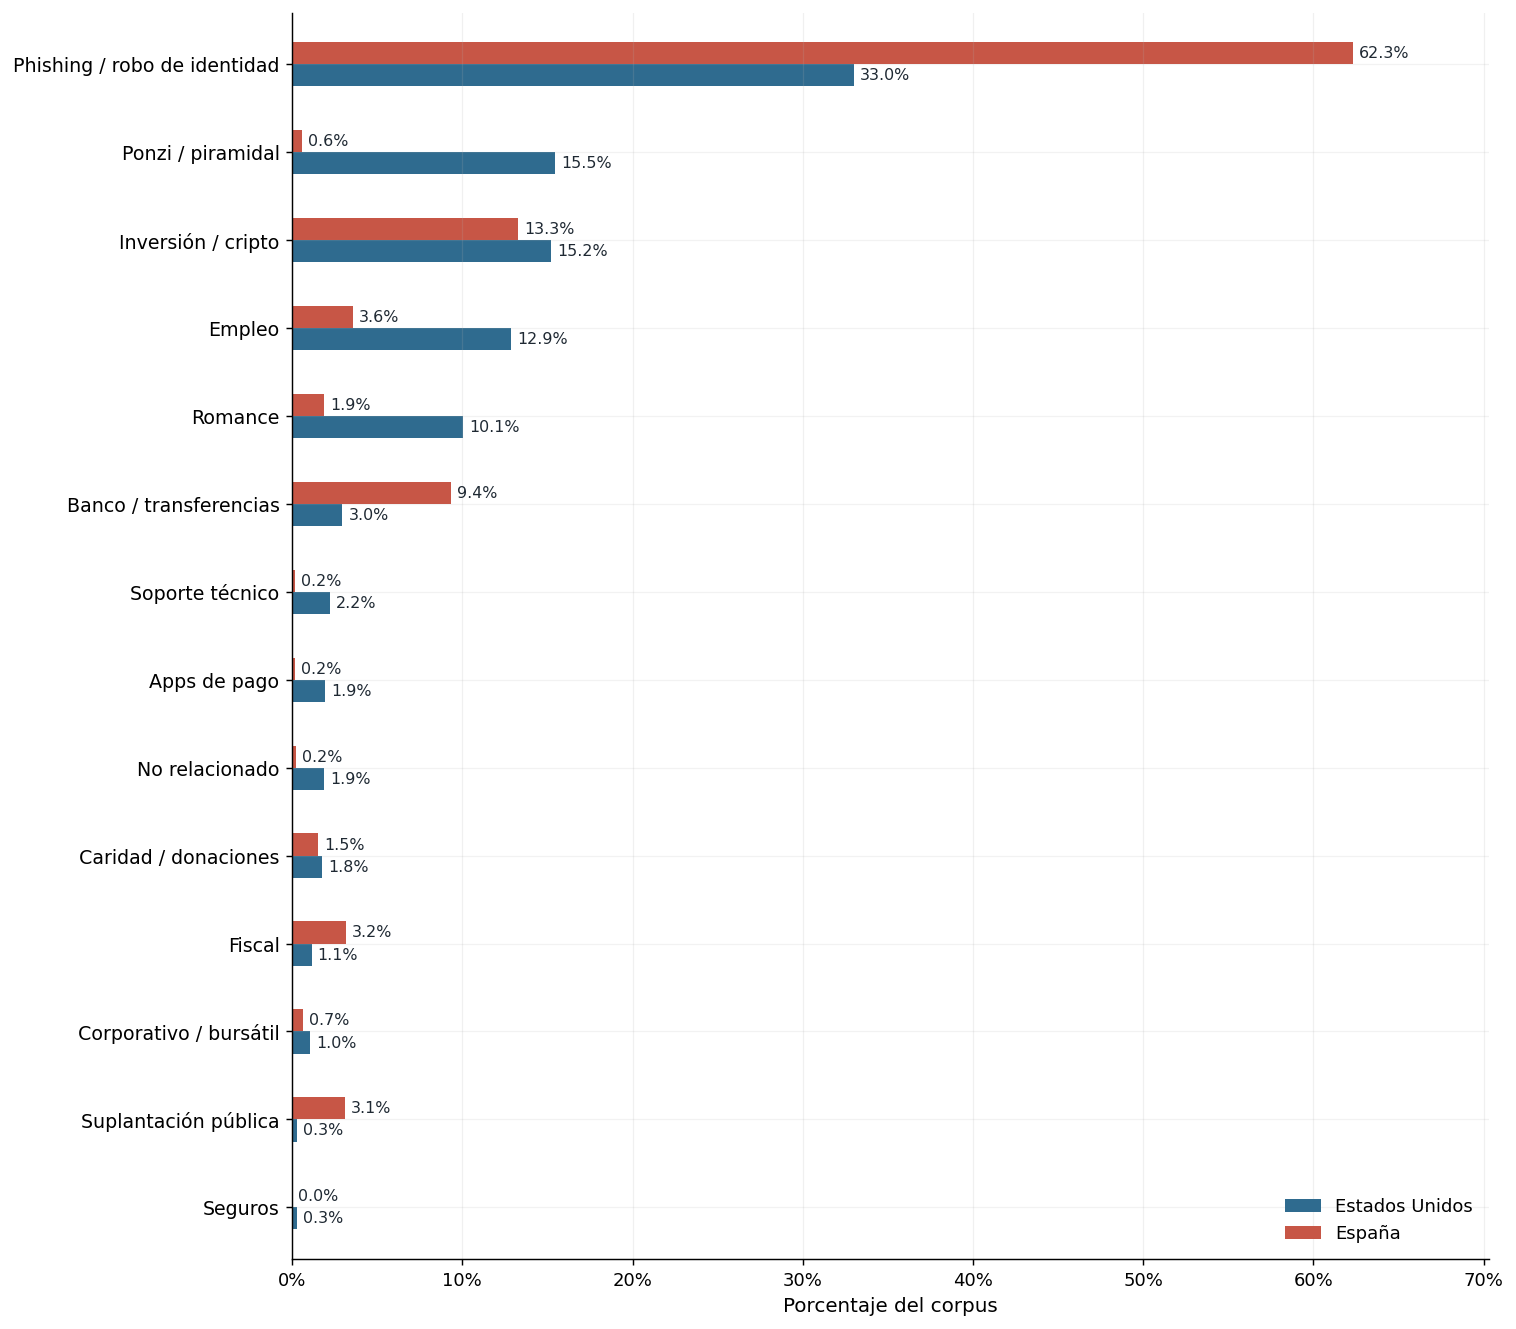

In [17]:
def category_distribution(df, prefix):
    counts = df["predicted_category"].value_counts()

    out = counts.rename(f"{prefix}_n").to_frame()
    out[f"{prefix}_pct"] = out[f"{prefix}_n"] / len(df) * 100

    return out


# ---------------------------------------------------------------------
# Tabla comparativa
# ---------------------------------------------------------------------

comp = (
    category_distribution(us, "us")
    .join(category_distribution(es, "es"), how="outer")
    .fillna(0)
)

comp = comp.reset_index(names="category")
comp["category_label"] = comp["category"].map(label_category)
comp["delta_es_us_pp"] = comp["es_pct"] - comp["us_pct"]

comp = (
    comp
    .sort_values(["us_pct", "es_pct"], ascending=False)
    .reset_index(drop=True)
)

tabla_categorias = comp[
    [
        "category_label",
        "us_n",
        "us_pct",
        "es_n",
        "es_pct",
        "delta_es_us_pp",
    ]
].copy()

tabla_categorias.columns = [
    "Categoría",
    "EEUU n",
    "EEUU %",
    "España n",
    "España %",
    "Diferencia España-EEUU (p.p.)",
]

for col in [
    "EEUU %",
    "España %",
    "Diferencia España-EEUU (p.p.)",
]:
    tabla_categorias[col] = tabla_categorias[col].round(1)

export_table(
    tabla_categorias,
    "tabla_distribucion_categorias",
    caption="Frecuencia absoluta y relativa por categoría predicha.",
    label="tab:distribucion_categorias",
)

display(tabla_categorias)


# ---------------------------------------------------------------------
# Gráfico comparativo
# ---------------------------------------------------------------------

# Orden ascendente para que las categorías más frecuentes aparezcan arriba
plot_df = (
    comp
    .sort_values(["us_pct", "es_pct"], ascending=True)
    .reset_index(drop=True)
)

# Más espacio vertical entre categorías
row_spacing = 1.35
y_positions = np.arange(len(plot_df)) * row_spacing

# Barras finas para que cada pareja respire
bar_height = 0.34

# Altura dinámica según el número de categorías
fig_height = max(9, len(plot_df) * 0.74)

fig, ax = plt.subplots(
    figsize=(11.8, fig_height)
)

bars_us = ax.barh(
    y_positions - bar_height / 2,
    plot_df["us_pct"],
    height=bar_height,
    label="Estados Unidos",
    color=COUNTRY_COLORS["Estados Unidos"],
)

bars_es = ax.barh(
    y_positions + bar_height / 2,
    plot_df["es_pct"],
    height=bar_height,
    label="España",
    color=COUNTRY_COLORS["España"],
)


def add_percentage_labels(ax, bars):
    """
    Coloca todos los porcentajes fuera de las barras,
    incluidos los valores iguales a 0,0 %.
    """
    for bar in bars:
        value = float(bar.get_width())
        y_bar = bar.get_y() + bar.get_height() / 2

        # Evita que los valores cero queden pegados al eje
        x_text = max(value + 0.35, 0.35)

        ax.text(
            x_text,
            y_bar,
            f"{value:.1f}%",
            ha="left",
            va="center",
            fontsize=8.8,
            color=COLORS["ink"],
            clip_on=False,
            zorder=5,
        )


add_percentage_labels(ax, bars_us)
add_percentage_labels(ax, bars_es)


# ---------------------------------------------------------------------
# Ejes y formato
# ---------------------------------------------------------------------

ax.set_yticks(y_positions)

ax.set_yticklabels(
    [
        wrap_label(label, 31)
        for label in plot_df["category_label"]
    ],
    fontsize=10.5,
)

ax.xaxis.set_major_formatter(
    FuncFormatter(pct_formatter)
)

ax.set_xlabel(
    "Porcentaje del corpus",
    fontsize=11,
)

max_pct = max(
    float(plot_df["us_pct"].max()),
    float(plot_df["es_pct"].max()),
)

# Espacio adicional para que las etiquetas exteriores no se corten
ax.set_xlim(
    0,
    max_pct + 8,
)

# Cuadrícula únicamente en el eje horizontal
ax.grid(
    axis="x",
    linestyle="-",
    linewidth=0.7,
    alpha=0.18,
)

# Más aire arriba y abajo
ax.margins(y=0.025)

# Limpieza visual
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    loc="lower right",
    frameon=False,
    fontsize=10,
)

fig.tight_layout(pad=1.2)

save_figure(
    fig,
    "fig_02_distribucion_categorias_comparada",
)

plt.show()

## 6. Figura: evolución mensual de las categorías principales

**Dónde:** Resultados, después de la distribución general.

**Versión elegida:** `version-final-visualizaciones/github2`, con etiquetas directas al final de las líneas.


Guardado: docs/overleaf/figures/fig_03_evolucion_mensual_categorias.png
Guardado: docs/overleaf/figures/fig_03_evolucion_mensual_categorias.pdf


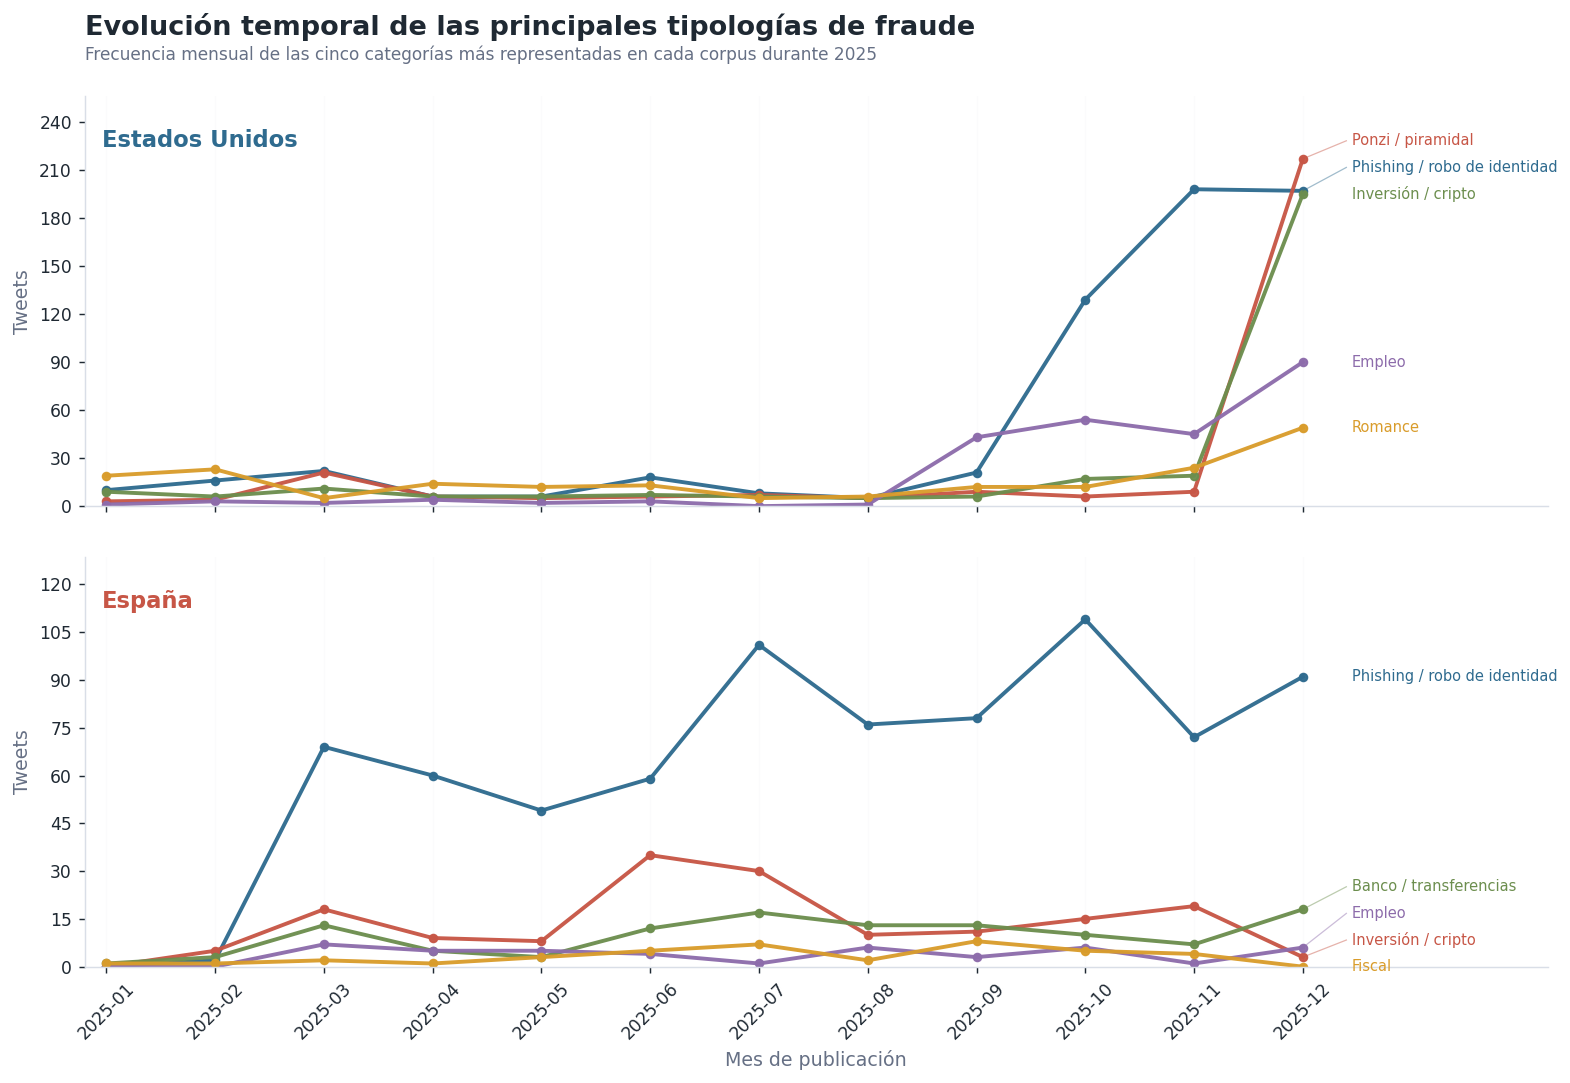

In [8]:
CATEGORY_COLORS = [COLORS["us"], COLORS["es"], COLORS["green"], COLORS["purple"], COLORS["gold"], COLORS["teal"], "#8C564B", "#7F7F7F"]


def monthly_top_categories(df, top_n=5):
    top = df["predicted_category"].value_counts().head(top_n).index.tolist()
    months = pd.period_range("2025-01", "2025-12", freq="M").astype(str)
    monthly = (
        df[df["predicted_category"].isin(top)]
        .groupby(["month", "predicted_category"])
        .size()
        .unstack(fill_value=0)
        .reindex(months, fill_value=0)
    )
    return monthly[top]


def place_end_labels(ax, monthly, colors):
    """Coloca etiquetas al final de las lineas evitando solapes verticales."""
    values = []
    ymax = ax.get_ylim()[1]
    min_gap = ymax * 0.065
    for i, category in enumerate(monthly.columns):
        values.append({
            "category": category,
            "label": label_category(category),
            "y": float(monthly[category].iloc[-1]),
            "color": colors[i],
        })

    values = sorted(values, key=lambda d: d["y"])
    adjusted = []
    for item in values:
        y_adj = item["y"]
        if adjusted and y_adj - adjusted[-1]["y_adj"] < min_gap:
            y_adj = adjusted[-1]["y_adj"] + min_gap
        item["y_adj"] = min(y_adj, ymax * 0.96)
        adjusted.append(item)

    # Si al empujar hacia arriba se pasa, compacta desde arriba hacia abajo.
    for j in range(len(adjusted) - 2, -1, -1):
        if adjusted[j + 1]["y_adj"] - adjusted[j]["y_adj"] < min_gap:
            adjusted[j]["y_adj"] = max(0, adjusted[j + 1]["y_adj"] - min_gap)

    x_text = len(monthly.index) - 0.55
    for item in adjusted:
        ax.text(
            x_text,
            item["y_adj"],
            item["label"],
            fontsize=8.1,
            color=item["color"],
            va="center",
            ha="left",
            clip_on=False,
        )
        # Pequena guia si la etiqueta se ha movido.
        if abs(item["y_adj"] - item["y"]) > 1:
            ax.plot([len(monthly.index) - 1.0, x_text - 0.05], [item["y"], item["y_adj"]], color=item["color"], linewidth=0.7, alpha=0.45, clip_on=False)


monthly_us = monthly_top_categories(us)
monthly_es = monthly_top_categories(es)

fig, axes = plt.subplots(2, 1, figsize=(12.4, 8.4), sharex=True)

for ax, monthly, panel_label in [
    (axes[0], monthly_us, "Estados Unidos"),
    (axes[1], monthly_es, "España"),
]:
    for i, category in enumerate(monthly.columns):
        ax.plot(
            monthly.index,
            monthly[category],
            marker="o",
            linewidth=2.15,
            markersize=4.3,
            label=label_category(category),
            color=CATEGORY_COLORS[i],
            alpha=0.96,
        )

    ax.set_ylim(0, max(monthly.max().max() * 1.18, 12))
    place_end_labels(ax, monthly, CATEGORY_COLORS)
    ax.text(0.012, 0.92, panel_label, transform=ax.transAxes, fontsize=12.5, fontweight="bold", va="top", color=COUNTRY_COLORS[panel_label])
    ax.set_ylabel("Tweets")
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    clean_axis(ax)
    ax.margins(x=0.04)

axes[0].text(0.00, 1.15, "Evolución temporal de las principales tipologías de fraude", transform=axes[0].transAxes, fontsize=15, fontweight="bold", color=COLORS["ink"], ha="left")
axes[0].text(0.00, 1.09, "Frecuencia mensual de las cinco categorías más representadas en cada corpus durante 2025", transform=axes[0].transAxes, fontsize=9.4, color=COLORS["muted"], ha="left")

axes[-1].set_xlabel("Mes de publicación")
axes[-1].tick_params(axis="x", rotation=45)

# Margen a la derecha para las etiquetas directas.
for ax in axes:
    ax.set_xlim(-0.2, 13.25)

fig.tight_layout(h_pad=2.2)
save_figure(fig, "fig_03_evolucion_mensual_categorias")
plt.show()

## 7. Figura: post-corrección española de la estafa del hijo en apuros

**Dónde:** Materiales y Métodos o Resultados.

**Versión elegida:** barras antes/después de `mejora-visualizaciones`.


Guardado: docs/overleaf/tables/tabla_postcorreccion_hijo_apuros.csv
Guardado: docs/overleaf/tables/tabla_postcorreccion_hijo_apuros.tex
Guardado: docs/overleaf/figures/fig_06_postcorreccion_hijo_apuros.png
Guardado: docs/overleaf/figures/fig_06_postcorreccion_hijo_apuros.pdf


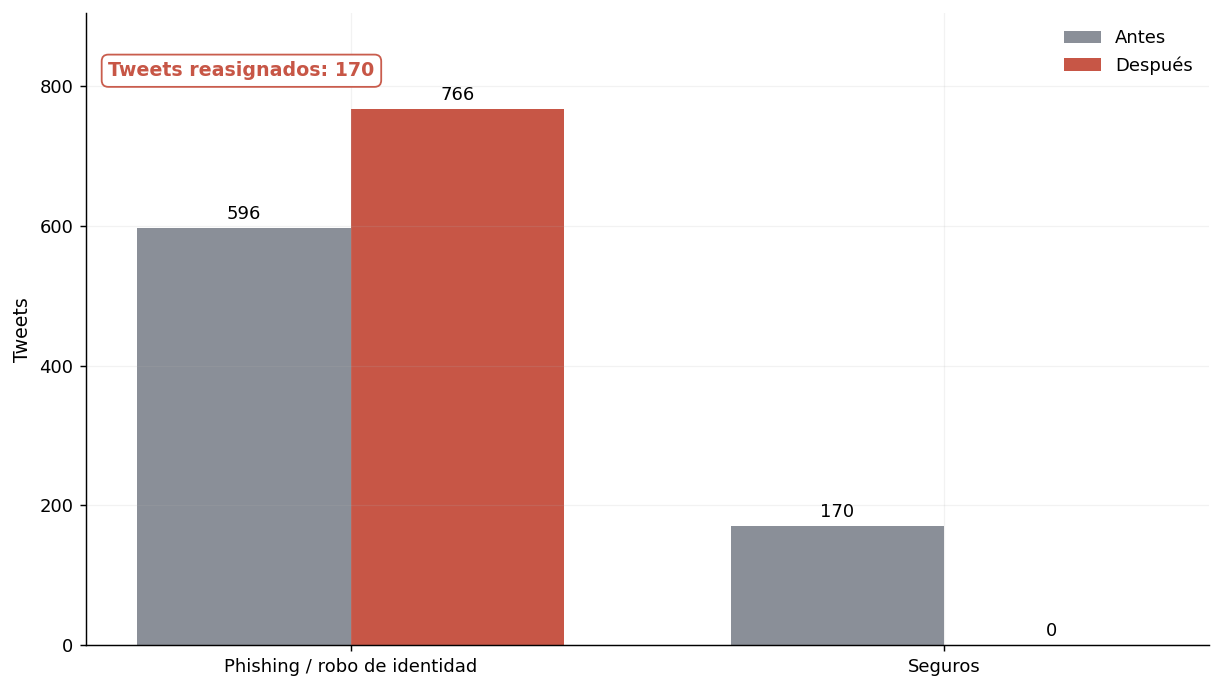

,Categoría,Antes,Después
0,Phishing / robo de identidad,596,766
1,Seguros,170,0


In [9]:
if "predicted_category_original" not in es.columns:
    print("El CSV español no contiene predicted_category_original; se omite esta figura.")
else:
    before = es["predicted_category_original"].fillna(es["predicted_category"])
    after = es["predicted_category"]
    changed = before.ne(after)
    corrected_n = int(changed.sum())
    focus_categories = ["phishing_identity", "insurance"]
    corr_df = pd.DataFrame({
        "Categoría": [label_category(cat) for cat in focus_categories],
        "Antes": [int((before == cat).sum()) for cat in focus_categories],
        "Después": [int((after == cat).sum()) for cat in focus_categories],
    })
    export_table(
        corr_df,
        "tabla_postcorreccion_hijo_apuros",
        caption="Efecto de la post-corrección de la estafa del hijo en apuros.",
        label="tab:postcorreccion_hijo_apuros",
    )

    x = np.arange(len(corr_df))
    width = 0.36
    fig, ax = plt.subplots(figsize=(9.5, 5.4))
    bars_before = ax.bar(x - width / 2, corr_df["Antes"], width, label="Antes", color="#8A8F98")
    bars_after = ax.bar(x + width / 2, corr_df["Después"], width, label="Después", color=COUNTRY_COLORS["España"])
    ax.set_xticks(x)
    ax.set_xticklabels(corr_df["Categoría"])
    ax.set_ylabel("Tweets")
    ax.set_ylim(0, max(corr_df[["Antes", "Después"]].to_numpy().max() * 1.18, 50))
    ax.legend()
    ax.bar_label(bars_before, padding=3)
    ax.bar_label(bars_after, padding=3)
    ax.text(
        0.02, 0.90, f"Tweets reasignados: {corrected_n}",
        transform=ax.transAxes, fontsize=10.5, fontweight="bold", color=COUNTRY_COLORS["España"],
        bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": COUNTRY_COLORS["España"], "linewidth": 1.0, "alpha": 0.96},
        zorder=10, clip_on=False,
    )
    fig.tight_layout()
    save_figure(fig, "fig_06_postcorreccion_hijo_apuros")
    plt.show()
    display(corr_df)


## 8. Figura: tópicos BERTopic del corpus estadounidense

**Versión elegida:** `version-final-visualizaciones/github2`, gráfico tipo lollipop.


Guardado: docs/overleaf/tables/tabla_topicos_bertopic_eeuu.csv
Guardado: docs/overleaf/tables/tabla_topicos_bertopic_eeuu.tex
Guardado: docs/overleaf/figures/fig_07_topicos_bertopic_eeuu.png
Guardado: docs/overleaf/figures/fig_07_topicos_bertopic_eeuu.pdf


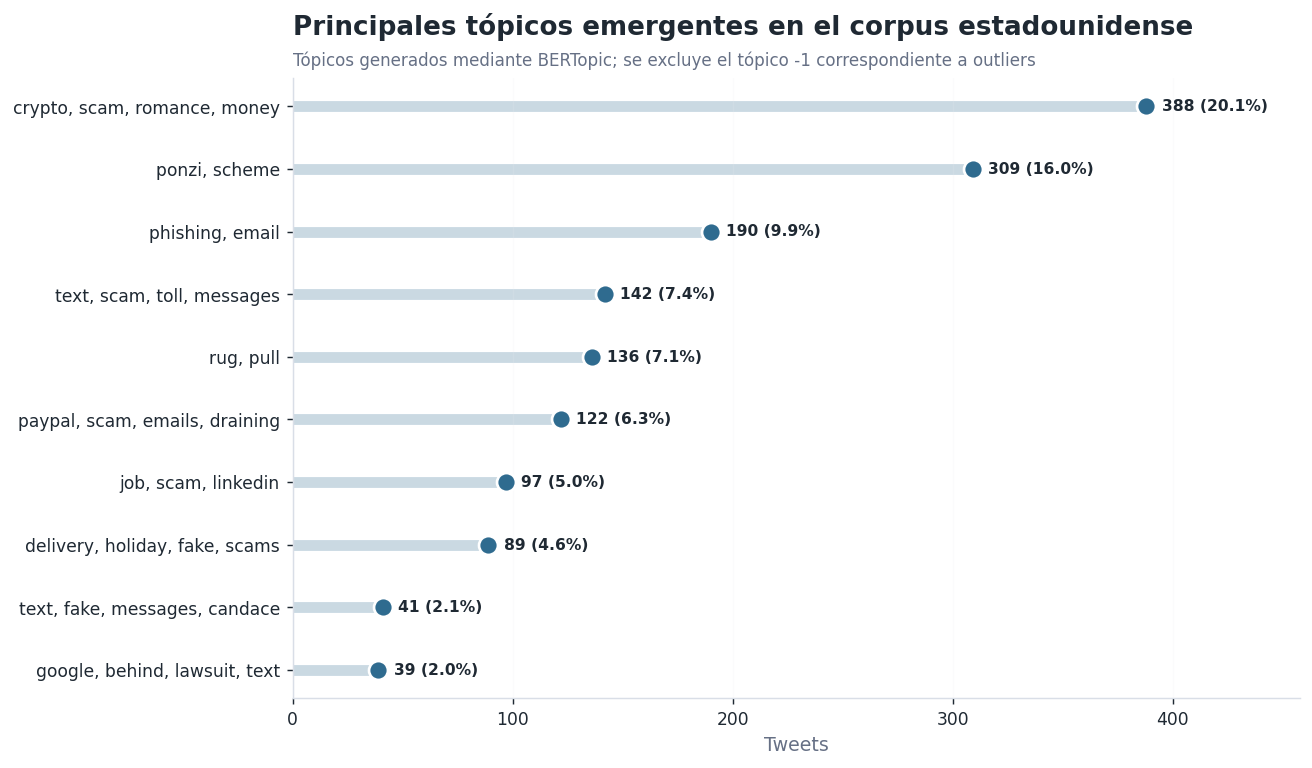

,Topic ID,Etiqueta visual,Tweets,% corpus,Keywords originales
1,0,"crypto, scam, romance, money",388,20.1,"crypto, scam, to, romance, money, and, in, for"
2,1,"ponzi, scheme",309,16.0,"ponzi, scheme, the, is, to, and, of, it"
3,2,"phishing, email",190,9.9,"phishing, email, and, it, to, your, the, you"
4,3,"text, scam, toll, messages",142,7.4,"text, scam, toll, the, to, messages, and, from"
5,4,"rug, pull",136,7.1,"rug, pull, the, this, is, be, to, will"
6,5,"paypal, scam, emails, draining",122,6.3,"paypal, scam, to, emails, the, draining, sneak..."
7,6,"job, scam, linkedin",97,5.0,"job, scam, to, for, the, linkedin, are, of"
8,7,"delivery, holiday, fake, scams",89,4.6,"delivery, holiday, fake, and, scams, package, ..."
9,8,"text, fake, messages, candace",41,2.1,"text, fake, messages, and, candace, her, the, she"
10,9,"google, behind, lawsuit, text",39,2.0,"google, behind, lawsuit, text, china, lighthou..."


In [10]:
def clean_topic_label(keyword_string, max_words=4):
    words = []
    for raw in str(keyword_string).split(","):
        word = raw.strip().lower()
        word = re.sub(r"\s+", " ", word)
        if word and word not in TOPIC_STOPWORDS and word not in words:
            words.append(word)
    return ", ".join(words[:max_words]) if words else str(keyword_string)


def topic_summary(df, top_n=10):
    if "bertopic_id" not in df.columns or "bertopic_keywords" not in df.columns:
        return pd.DataFrame()
    topics = (
        df.groupby(["bertopic_id", "bertopic_keywords"])
        .size()
        .reset_index(name="n_tweets")
    )
    topics["bertopic_id_num"] = pd.to_numeric(topics["bertopic_id"], errors="coerce")
    topics = topics[topics["bertopic_id_num"] != -1]
    topics["pct"] = topics["n_tweets"] / len(df) * 100
    topics["topic_label"] = topics["bertopic_keywords"].map(clean_topic_label)
    return topics.sort_values("n_tweets", ascending=False).head(top_n)


def plot_topics_lollipop(topics, country_name, color, filename):
    plot_topics = topics.sort_values("n_tweets", ascending=True).copy()
    y = np.arange(len(plot_topics))

    fig, ax = plt.subplots(figsize=(10.2, 6.0))
    ax.hlines(y, 0, plot_topics["n_tweets"], color=color, alpha=0.25, linewidth=6, zorder=1)
    ax.scatter(plot_topics["n_tweets"], y, s=110, color=color, edgecolor="white", linewidth=1.5, zorder=3)

    ax.set_yticks(y)
    ax.set_yticklabels([wrap_label(t, 36) for t in plot_topics["topic_label"]])
    ax.set_xlabel("Tweets")
    clean_axis(ax)
    ax.set_xlim(0, plot_topics["n_tweets"].max() * 1.18)

    for i, row in enumerate(plot_topics.itertuples()):
        ax.text(row.n_tweets + plot_topics["n_tweets"].max() * 0.018, i, f"{row.n_tweets} ({row.pct:.1f}%)", va="center", fontsize=8.6, color=COLORS["ink"], fontweight="bold")

    ax.text(0.00, 1.07, f"Principales tópicos emergentes en el corpus {country_name}", transform=ax.transAxes, fontsize=14.5, fontweight="bold", color=COLORS["ink"], ha="left")
    ax.text(0.00, 1.02, "Tópicos generados mediante BERTopic; se excluye el tópico -1 correspondiente a outliers", transform=ax.transAxes, fontsize=9.3, color=COLORS["muted"], ha="left")

    fig.tight_layout()
    save_figure(fig, filename)
    plt.show()


topics_us = topic_summary(us, top_n=10)
topics_us_table = topics_us[["bertopic_id", "topic_label", "n_tweets", "pct", "bertopic_keywords"]].copy()
topics_us_table.columns = ["Topic ID", "Etiqueta visual", "Tweets", "% corpus", "Keywords originales"]
topics_us_table["% corpus"] = topics_us_table["% corpus"].round(1)

export_table(
    topics_us_table,
    "tabla_topicos_bertopic_eeuu",
    caption="Tópicos BERTopic principales del corpus estadounidense.",
    label="tab:topicos_bertopic_eeuu",
)

plot_topics_lollipop(topics_us, "estadounidense", COUNTRY_COLORS["Estados Unidos"], "fig_07_topicos_bertopic_eeuu")
display(topics_us_table)

## 9. Figura: tópicos BERTopic del corpus español

**Versión elegida:** `version-final-visualizaciones/github2`, gráfico tipo lollipop.


Guardado: docs/overleaf/tables/tabla_topicos_bertopic_espana.csv
Guardado: docs/overleaf/tables/tabla_topicos_bertopic_espana.tex
Guardado: docs/overleaf/figures/fig_08_topicos_bertopic_espana.png
Guardado: docs/overleaf/figures/fig_08_topicos_bertopic_espana.pdf


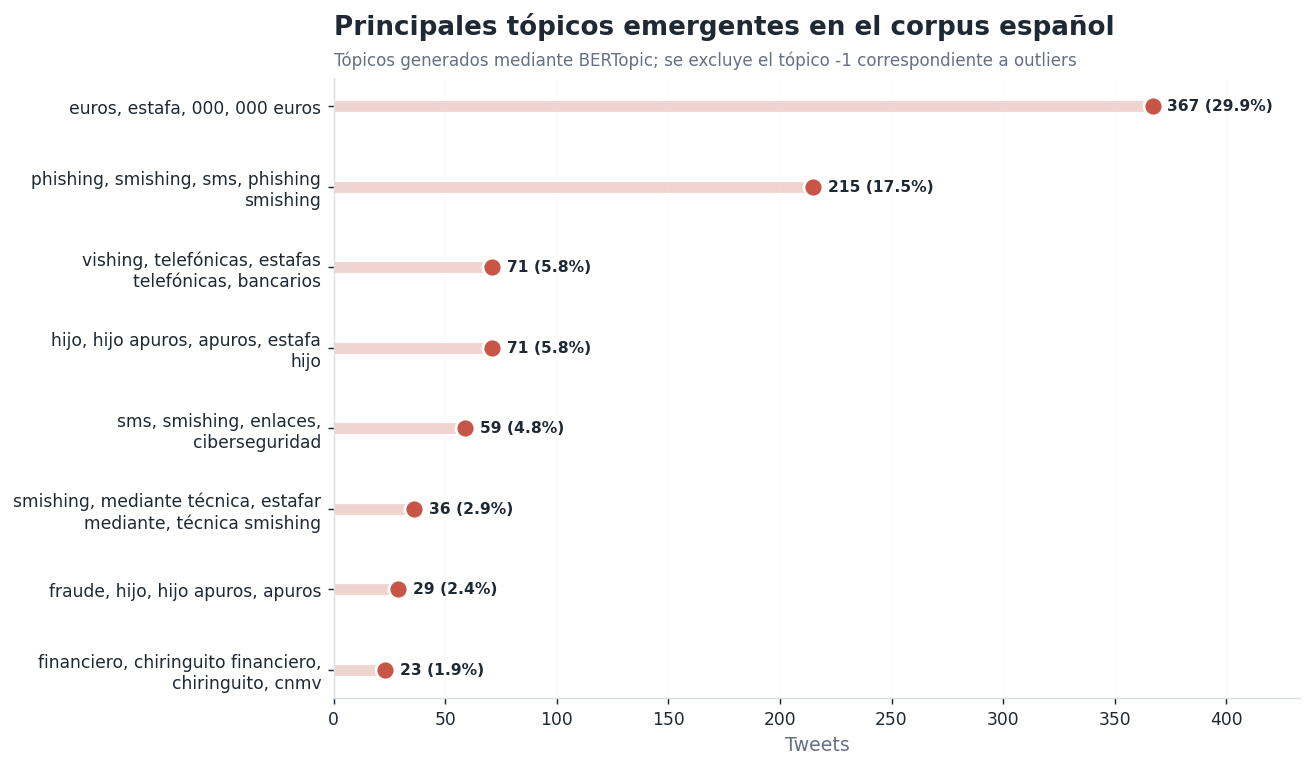

,Topic ID,Etiqueta visual,Tweets,% corpus,Keywords originales
1,0,"euros, estafa, 000, 000 euros",367,29.9,"euros, estafa, 000, 000 euros, hijo, apuros, h..."
2,1,"phishing, smishing, sms, phishing smishing",215,17.5,"phishing, smishing, sms, phishing smishing, da..."
3,2,"hijo, hijo apuros, apuros, estafa hijo",71,5.8,"hijo, hijo apuros, apuros, estafa hijo, estafa..."
4,3,"vishing, telefónicas, estafas telefónicas, ban...",71,5.8,"vishing, telefónicas, estafas telefónicas, ban..."
5,4,"sms, smishing, enlaces, ciberseguridad",59,4.8,"sms, smishing, enlaces, ciberseguridad, clic, ..."
6,5,"smishing, mediante técnica, estafar mediante, ...",36,2.9,"smishing, mediante, mediante técnica, estafar ..."
7,6,"fraude, hijo, hijo apuros, apuros",29,2.4,"fraude, hijo, hijo apuros, apuros, criminal, w..."
8,7,"financiero, chiringuito financiero, chiringuit...",23,1.9,"financiero, chiringuito financiero, chiringuit..."


In [11]:
topics_es = topic_summary(es, top_n=10)

if topics_es.empty:
    print("No hay columnas BERTopic en el corpus español.")
else:
    largest_share = topics_es["pct"].max()
    if largest_share > 70:
        print(f"AVISO: el tópico principal supera el 70% del corpus ({largest_share:.1f}%).")
        print("Recomendación: ejecutar notebooks/11_bertopic_espana_stopwords.ipynb antes de generar la figura.")
    else:
        topics_es_table = topics_es[["bertopic_id", "topic_label", "n_tweets", "pct", "bertopic_keywords"]].copy()
        topics_es_table.columns = ["Topic ID", "Etiqueta visual", "Tweets", "% corpus", "Keywords originales"]
        topics_es_table["% corpus"] = topics_es_table["% corpus"].round(1)

        export_table(
            topics_es_table,
            "tabla_topicos_bertopic_espana",
            caption="Tópicos BERTopic principales del corpus español.",
            label="tab:topicos_bertopic_espana",
        )

        plot_topics_lollipop(topics_es, "español", COUNTRY_COLORS["España"], "fig_08_topicos_bertopic_espana")
        display(topics_es_table)

## 10. Resumen de archivos generados

Verifica que las figuras finales se hayan exportado correctamente antes del commit.


In [12]:
expected = [
    "fig_00a_pipeline_color.png",
    "fig_00b_pipeline_bn.png",
    "fig_01_flujo_construccion_corpus.png",
    "fig_02_distribucion_categorias_comparada.png",
    "fig_03_evolucion_mensual_categorias.png",
    "fig_06_postcorreccion_hijo_apuros.png",
    "fig_07_topicos_bertopic_eeuu.png",
    "fig_08_topicos_bertopic_espana.png",
]

print("Comprobación de figuras finales:")
for filename in expected:
    path = FIG_DIR / filename
    status = "OK" if path.exists() else "FALTA"
    print(f"[{status}] {path.relative_to(REPO_ROOT)}")

print("\nTablas CSV generadas:")
for path in sorted(TABLE_DIR.glob("*.csv")):
    print(f"- {path.relative_to(REPO_ROOT)}")


Comprobación de figuras finales:
[OK] docs/overleaf/figures/fig_00a_pipeline_color.png
[OK] docs/overleaf/figures/fig_00b_pipeline_bn.png
[OK] docs/overleaf/figures/fig_01_flujo_construccion_corpus.png
[OK] docs/overleaf/figures/fig_02_distribucion_categorias_comparada.png
[OK] docs/overleaf/figures/fig_03_evolucion_mensual_categorias.png
[OK] docs/overleaf/figures/fig_06_postcorreccion_hijo_apuros.png
[OK] docs/overleaf/figures/fig_07_topicos_bertopic_eeuu.png
[OK] docs/overleaf/figures/fig_08_topicos_bertopic_espana.png

Tablas CSV generadas:
- docs/overleaf/tables/tabla_caracteristicas_corpus.csv
- docs/overleaf/tables/tabla_distribucion_categorias.csv
- docs/overleaf/tables/tabla_postcorreccion_hijo_apuros.csv
- docs/overleaf/tables/tabla_topicos_bertopic_eeuu.csv
- docs/overleaf/tables/tabla_topicos_bertopic_espana.csv
